In [119]:
import os
import re

import matplotlib.pyplot as plt

In [120]:
log_file = "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_class_mini_first_cyclization_run_02/train.log"

with open(log_file) as f:
    raw = f.read()

relevant_lines = [
    line for line in raw.splitlines()
    if re.search(r"\[byprot\.tasks\]\[INFO\].*Validation Info @", line)
]
log = "\n".join(relevant_lines)

In [121]:
checkpoints = list(range(1_000, 22_001, 1_000))

In [122]:
save_to = os.path.join(os.path.dirname(os.path.abspath(log_file)), "training_plots")
os.makedirs(save_to, exist_ok=True)


In [123]:
def extract_metrics(log, n=1):
    epochs = []
    global_steps = []
    losses = []
    nll_loss = []
    ppl = []
    ppl_best = []
    acc = []
    acc_best = []
    acc_median = []
    acc_median_best = []
    for line in log.strip().split("\n"):
        match = re.search(r"Epoch (\d+), global step (\d+)\):.*val/loss=([\d.]+)", line)
        if match:
            epochs.append(int(match.group(1)))
            global_steps.append(int(match.group(2)))
            losses.append(float(match.group(3)))
    for line in log.strip().split("\n"):
        match = re.search(r"Epoch (\d+), global step \d+\):.*val/nll_loss=([\d.]+)", line)
        if match:
            nll_loss.append(float(match.group(2)))
    for line in log.strip().split("\n"):
        match = re.search(r"Epoch (\d+), global step \d+\):.*val/ppl=([\d.]+)", line)
        if match:
            ppl.append(float(match.group(2)))
    for line in log.strip().split("\n"):
        match = re.search(r"Epoch (\d+), global step \d+\):.*val/ppl_best=([\d.]+)", line)
        if match:
            ppl_best.append(float(match.group(2)))
    for line in log.strip().split("\n"):
        match = re.search(r"Epoch (\d+), global step \d+\):.*val/acc=([\d.]+)", line)
        if match:
            acc.append(float(match.group(2)))
    for line in log.strip().split("\n"):
        match = re.search(r"Epoch (\d+), global step \d+\):.*val/acc_best=([\d.]+)", line)
        if match:
            acc_best.append(float(match.group(2)))
    for line in log.strip().split("\n"):
        match = re.search(r"Epoch (\d+), global step \d+\):.*val/acc_median=([\d.]+)", line)
        if match:
            acc_median.append(float(match.group(2)))
    for line in log.strip().split("\n"):
        match = re.search(r"Epoch (\d+), global step \d+\):.*val/acc_median_best=([\d.]+)", line)
        if match:
            acc_median_best.append(float(match.group(2)))
    return epochs, global_steps, losses, nll_loss, ppl, ppl_best, acc, acc_best, acc_median, acc_median_best

(
    epochs,
    global_steps,
    losses,
    nll_loss,
    ppl,
    ppl_best,
    acc,
    acc_best,
    acc_median,
    acc_median_best,
) = extract_metrics(log, n=2)


print(epochs)
print(global_steps)
print(losses)
print(nll_loss)
print(ppl)
print(ppl_best)

[0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 2

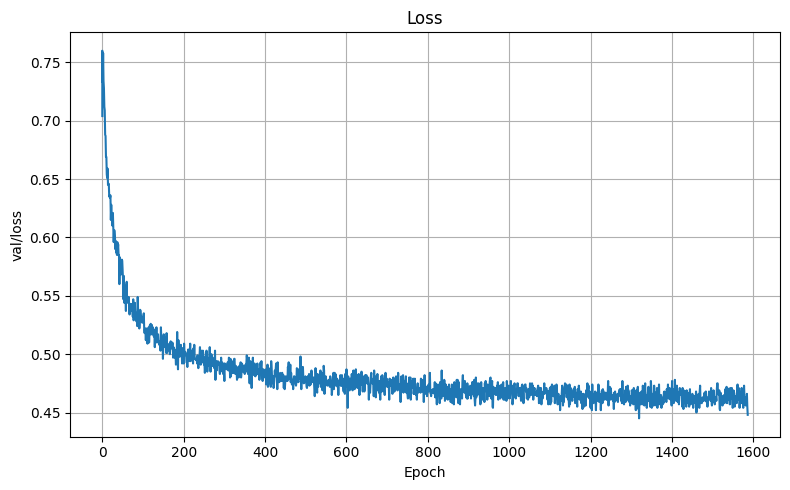

In [124]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, losses, marker="")
plt.xlabel("Epoch")
plt.ylabel("val/loss")
plt.title("Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_to}/loss.png")
plt.show()

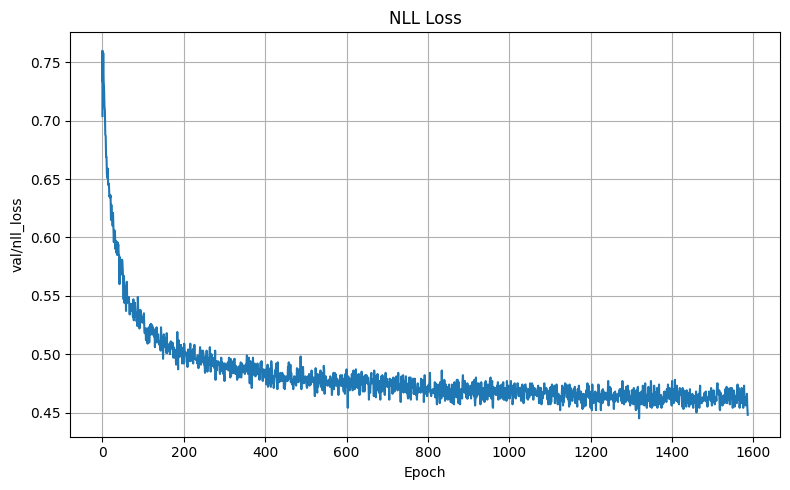

In [125]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, nll_loss, marker="")
plt.xlabel("Epoch")
plt.ylabel("val/nll_loss")
plt.title("NLL Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_to}/NLL_loss.png")
plt.show()

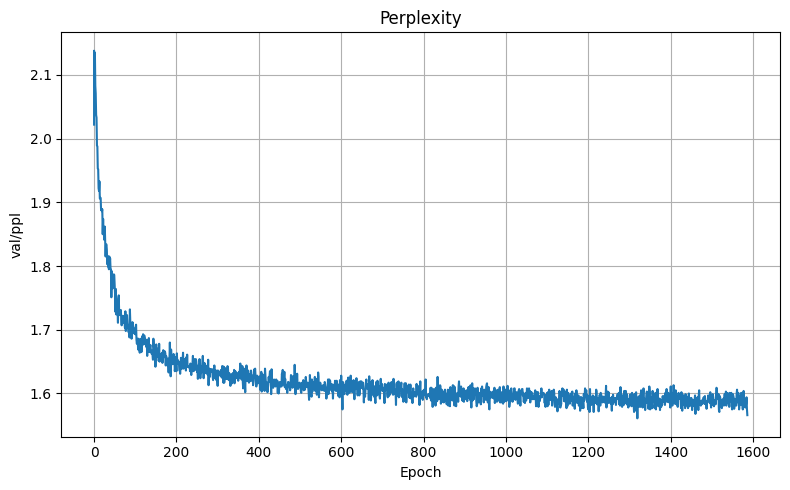

In [126]:
# ChatGPT Summary of ppl metric:
# ppl (Perplexity) — Model-Level Metric
# What it measures: How well the trained language model predicts or generates sequences.
#
# Scope: Evaluates the model's understanding of protein sequence patterns.
#
# When it's used: During training or evaluation of a protein language model (like DPLM).
#
# Lower is better: A lower perplexity indicates the model is more confident and accurate in predicting sequences.

plt.figure(figsize=(8, 5))
plt.plot(epochs, ppl, marker="")
plt.xlabel("Epoch")
plt.ylabel("val/ppl")
plt.title("Perplexity")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_to}/perplexity.png")
plt.show()

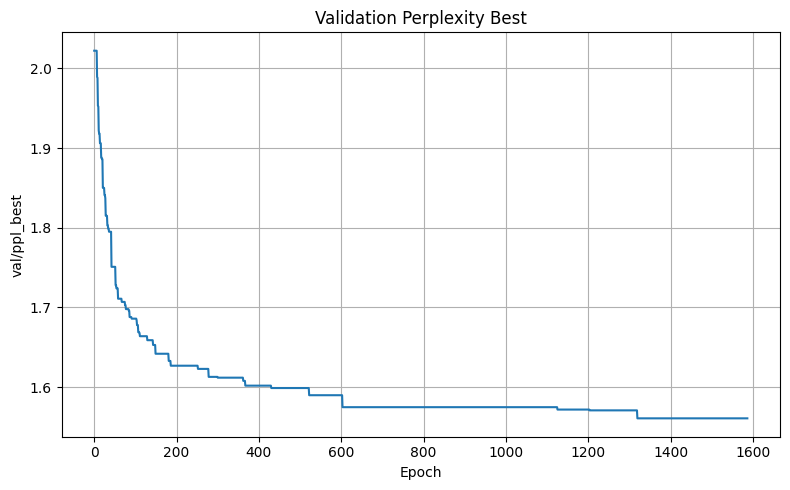

In [127]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, ppl_best, marker="")
plt.xlabel("Epoch")
plt.ylabel("val/ppl_best")
plt.title("Validation Perplexity Best")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_to}/perplexity_best.png")
plt.show()

/var/folders/mx/4d2y4srs4qg4brtqkqkls36m0000gn/T/ipykernel_71554/316156595.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


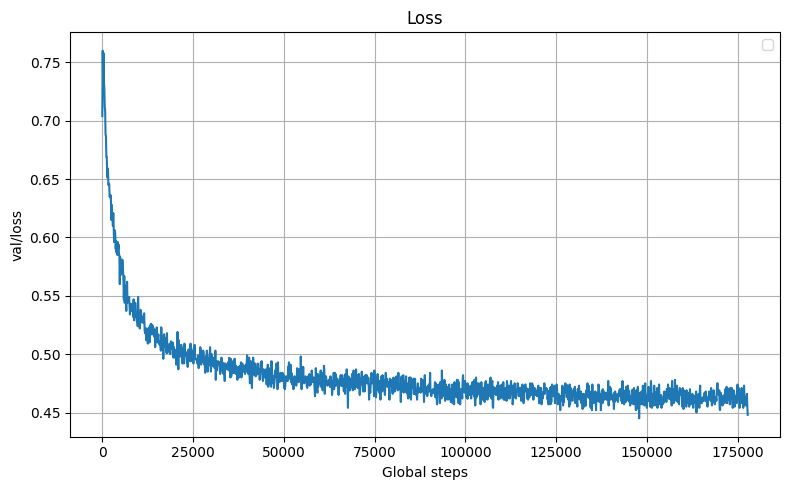

In [128]:
plt.figure(figsize=(8, 5))
plt.plot(global_steps, losses, marker="")
#plt.scatter(checkpoints, [losses[global_steps.index(cp)] for cp in checkpoints], color="red", s=20, zorder=5, label="Checkpoints")
plt.legend()
plt.xlabel("Global steps")
plt.ylabel("val/loss")
plt.title("Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_to}/loss_global_steps.png")
plt.show()

/var/folders/mx/4d2y4srs4qg4brtqkqkls36m0000gn/T/ipykernel_71554/3462143020.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


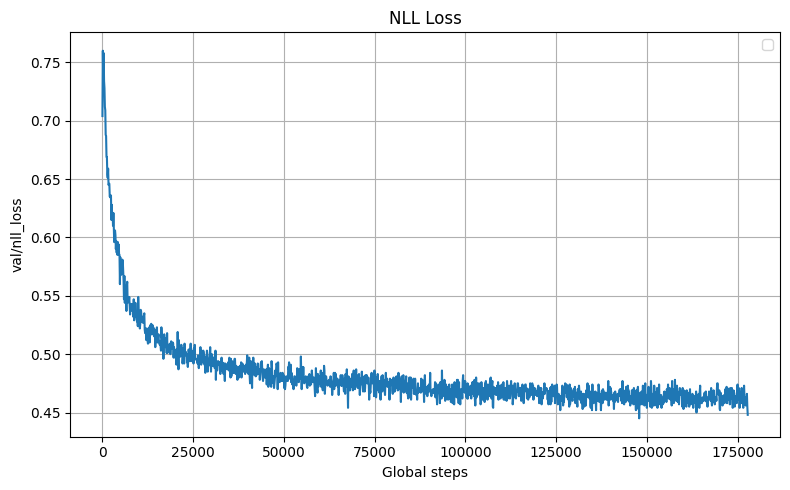

In [129]:
plt.figure(figsize=(8, 5))
plt.plot(global_steps, nll_loss, marker="")
#plt.scatter(checkpoints, [nll_loss[global_steps.index(cp)] for cp in checkpoints], color="red", s=20, zorder=5, label="Checkpoints")
plt.legend()
plt.xlabel("Global steps")
plt.ylabel("val/nll_loss")
plt.title("NLL Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_to}/NLL_loss_global_steps.png")
plt.show()

/var/folders/mx/4d2y4srs4qg4brtqkqkls36m0000gn/T/ipykernel_71554/1915863912.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


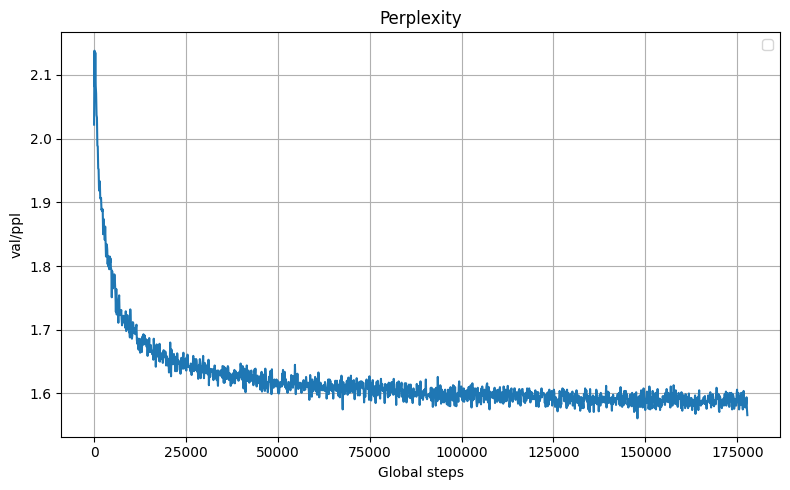

In [130]:
plt.figure(figsize=(8, 5))
plt.plot(global_steps, ppl, marker="")
#plt.scatter(checkpoints, [ppl[global_steps.index(cp)] for cp in checkpoints], color="red", s=20, zorder=5, label="Checkpoints")
plt.legend()
plt.xlabel("Global steps")
plt.ylabel("val/ppl")
plt.title("Perplexity")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_to}/perplexity_global_steps.png")
plt.show()

/var/folders/mx/4d2y4srs4qg4brtqkqkls36m0000gn/T/ipykernel_71554/3872587623.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


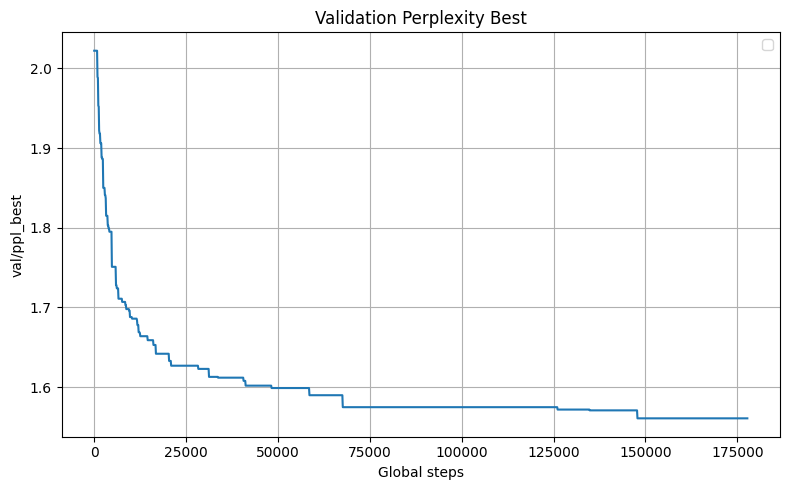

In [131]:
plt.figure(figsize=(8, 5))
plt.plot(global_steps, ppl_best, marker="")
#plt.scatter(checkpoints, [ppl_best[global_steps.index(cp)] for cp in checkpoints], color="red", s=20, zorder=5, label="Checkpoints")
plt.legend()
plt.xlabel("Global steps")
plt.ylabel("val/ppl_best")
plt.title("Validation Perplexity Best")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_to}/perplexity_best_global_steps.png")
plt.show()

/var/folders/mx/4d2y4srs4qg4brtqkqkls36m0000gn/T/ipykernel_71554/779235485.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


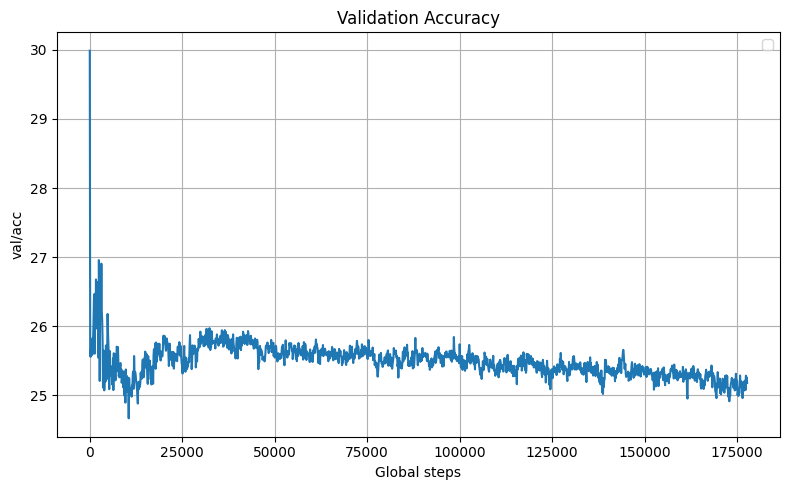

In [132]:
plt.figure(figsize=(8, 5))
plt.plot(global_steps, acc, marker="")
#plt.scatter(checkpoints, [acc[global_steps.index(cp)] for cp in checkpoints], color="red", s=20, zorder=5, label="Checkpoints")
plt.legend()
plt.xlabel("Global steps")
plt.ylabel("val/acc")
plt.title("Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_to}/accuracy_global_steps.png")
plt.show()

Scanning local path '/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_class_mini_first_cyclization_run_02/enzyme_explorer_validation' for CSV files...
Found 16 folders: ['epoch_0', 'epoch_100', 'epoch_200', 'epoch_300', 'epoch_400', 'epoch_500', 'epoch_600', 'epoch_700', 'epoch_800', 'epoch_900', 'epoch_1000', 'epoch_1100', 'epoch_1200', 'epoch_1300', 'epoch_1400', 'epoch_1500']
Processing folder 'epoch_0' with 1 CSV files...
Processing folder 'epoch_100' with 1 CSV files...
Processing folder 'epoch_200' with 1 CSV files...
Processing folder 'epoch_300' with 1 CSV files...
Processing folder 'epoch_400' with 1 CSV files...
Processing folder 'epoch_500' with 1 CSV files...
Processing folder 'epoch_600' with 1 CSV files...
Processing folder 'epoch_700' with 1 CSV files...
Processing folder 'epoch_800' with 1 CSV files...
Processing folder 'epoch_900' with 1 CSV files...
Processing folder 'epoch_1000' with 1 CSV files...
Processing folder 'epoch_1100' with 1 

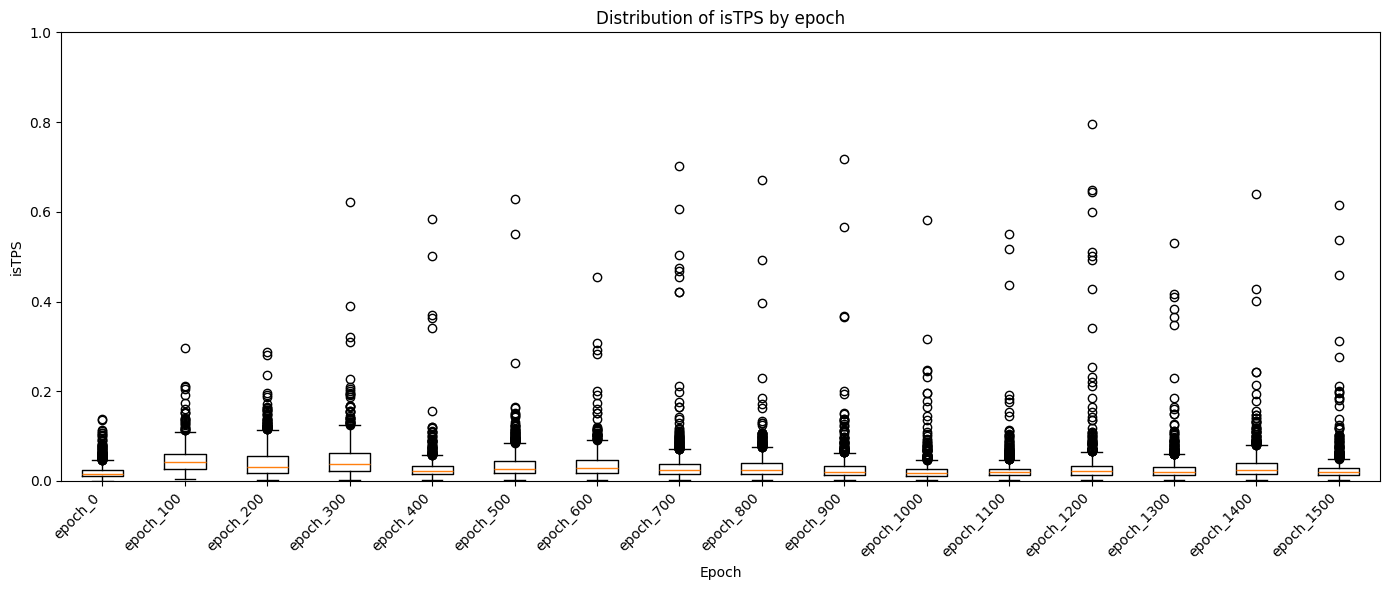

Saved plot to: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_class_mini_first_cyclization_run_02/enzyme_explorer_validation/isTPS_by_epoch_boxplot.png


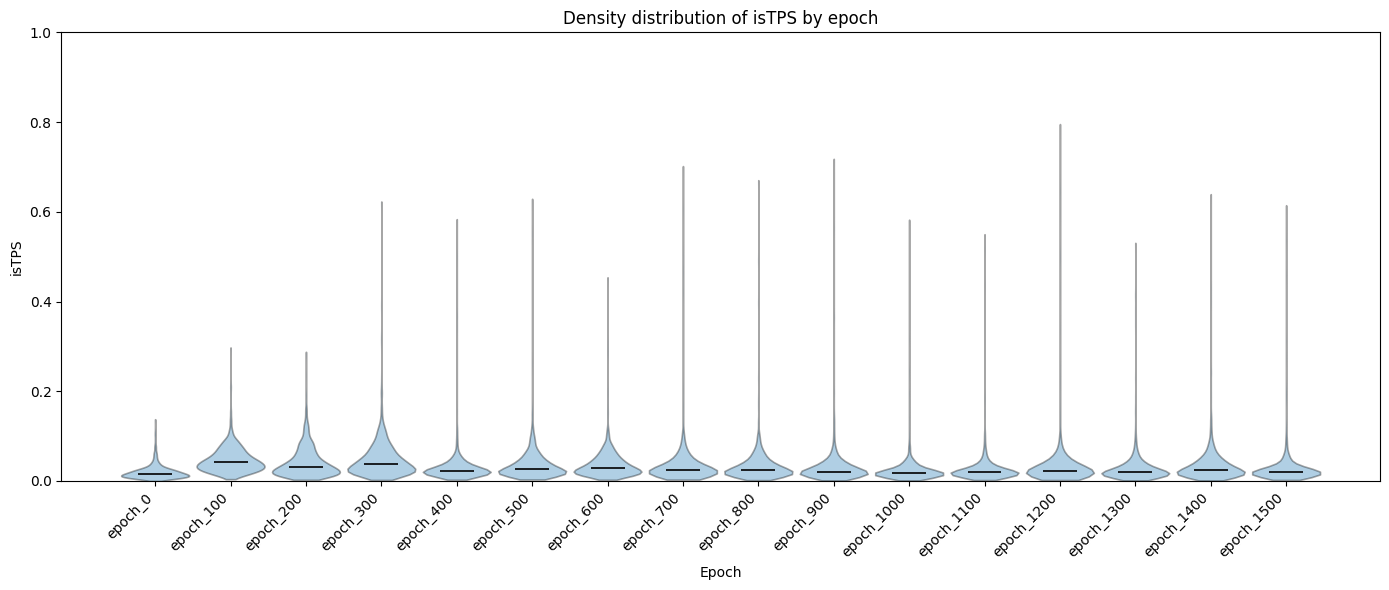

Saved plot to: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_class_mini_first_cyclization_run_02/enzyme_explorer_validation/isTPS_by_epoch_violin.png


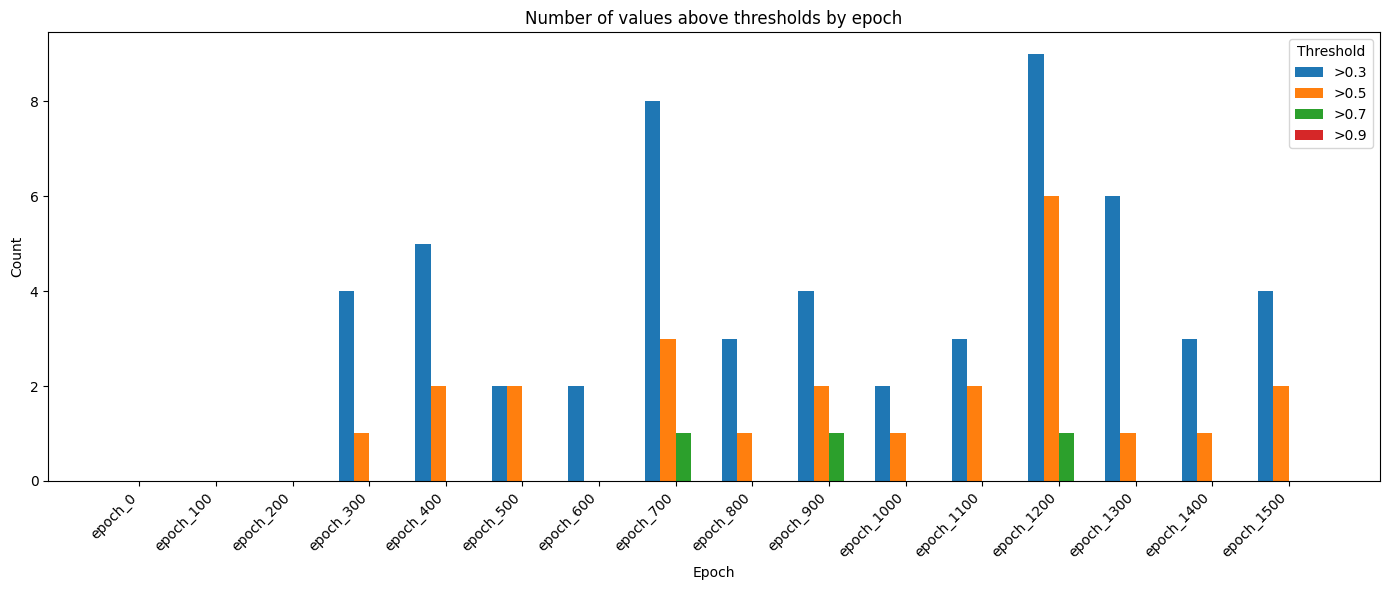

Saved plot to: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_class_mini_first_cyclization_run_02/enzyme_explorer_validation/isTPS_by_epoch_counts.png


In [133]:
from pathlib import Path

import numpy as np
import pandas as pd

TARGET_COLUMN_NAME = "isTPS "
enzyme_explorer_path = Path(log_file).resolve().parent / "enzyme_explorer_validation"

if enzyme_explorer_path.exists():
    print(f"Scanning local path '{enzyme_explorer_path}' for CSV files...")
    folders = sorted(
        [path for path in enzyme_explorer_path.iterdir() if path.is_dir()],
        key=lambda path: (0, int(path.name.split("_")[-1]))
        if path.name.startswith("epoch_") and path.name.split("_")[-1].isdigit()
        else (1, path.name),
    )
    print(f"Found {len(folders)} folders: {[folder.name for folder in folders]}")

    rows = []
    for folder in folders:
        csv_files = sorted(folder.glob("*.csv"))
        print(f"Processing folder '{folder.name}' with {len(csv_files)} CSV files...")
        if not csv_files:
            continue

        for csv_file in csv_files:
            try:
                df = pd.read_csv(csv_file)
            except Exception as error:
                print(f"Error reading {csv_file}: {error}")
                continue

            value_column = None
            if TARGET_COLUMN_NAME in df.columns:
                value_column = TARGET_COLUMN_NAME
            else:
                normalized_columns = {column.strip(): column for column in df.columns}
                value_column = normalized_columns.get(TARGET_COLUMN_NAME.strip())

            if value_column is None:
                print(f"Column '{TARGET_COLUMN_NAME}' not found in {csv_file}")
                continue

            values = pd.to_numeric(df[value_column], errors="coerce").dropna()
            rows.extend((folder.name, value) for value in values)

    if rows:
        plot_df = pd.DataFrame(rows, columns=["folder", TARGET_COLUMN_NAME])
        plot_df[TARGET_COLUMN_NAME] = pd.to_numeric(plot_df[TARGET_COLUMN_NAME], errors="coerce")

        available_folders = set(plot_df["folder"])
        folder_order = [folder.name for folder in folders if folder.name in available_folders]
        value_col = TARGET_COLUMN_NAME

        box_data = [
            plot_df.loc[plot_df["folder"] == folder_name, value_col].dropna()
            for folder_name in folder_order
        ]

        fig, ax = plt.subplots(figsize=(14, 6))
        ax.boxplot(box_data, tick_labels=folder_order)
        ax.set_title(f"Distribution of {value_col.strip()} by epoch")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(value_col.strip())
        ax.set_ylim(0.0, 1.0)

        PLOT_LINEAR_FIT = False
        if PLOT_LINEAR_FIT:
            folder_to_x = {folder_name: index + 1 for index, folder_name in enumerate(folder_order)}
            fit_df = plot_df[plot_df["folder"].isin(folder_order)].copy()
            fit_df["x"] = fit_df["folder"].map(folder_to_x)

            x_all = fit_df["x"].to_numpy(dtype=float)
            y_all = fit_df[value_col].to_numpy(dtype=float)
            mask = np.isfinite(x_all) & np.isfinite(y_all)

            if mask.sum() >= 2:
                slope, intercept = np.polyfit(x_all[mask], y_all[mask], 1)
                x_line = np.array([1, len(folder_order)], dtype=float)
                y_line = slope * x_line + intercept
                ax.plot(
                    x_line,
                    y_line,
                    color="crimson",
                    linewidth=2,
                    label=f"Linear fit (all values): y={slope:.4f}x+{intercept:.4f}",
                )
                ax.legend()

        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

        output_file = enzyme_explorer_path / f"{value_col.strip().replace(' ', '_')}_by_epoch_boxplot.png"
        fig.savefig(output_file, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {output_file}")

        violin_data = [
            pd.to_numeric(
                plot_df.loc[plot_df["folder"] == folder_name, value_col],
                errors="coerce",
            ).dropna().values
            for folder_name in folder_order
        ]

        fig3, ax3 = plt.subplots(figsize=(14, 6))
        parts = ax3.violinplot(
            violin_data,
            positions=np.arange(1, len(folder_order) + 1),
            widths=0.9,
            showmeans=False,
            showmedians=True,
            showextrema=False,
        )

        for body in parts["bodies"]:
            body.set_facecolor("#1f77b4")
            body.set_alpha(0.35)
            body.set_edgecolor("black")
            body.set_linewidth(1.2)

        parts["cmedians"].set_color("black")
        parts["cmedians"].set_linewidth(1.2)

        ax3.set_title(f"Density distribution of {value_col.strip()} by epoch")
        ax3.set_xlabel("Epoch")
        ax3.set_ylabel(value_col.strip())
        ax3.set_ylim(0.0, 1.0)
        ax3.set_xticks(np.arange(1, len(folder_order) + 1))
        ax3.set_xticklabels(folder_order, rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

        output_file = enzyme_explorer_path / f"{value_col.strip().replace(' ', '_')}_by_epoch_violin.png"
        fig3.savefig(output_file, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {output_file}")

        thresholds = [0.3, 0.5, 0.7, 0.9]
        counts = pd.DataFrame(index=folder_order)
        for threshold in thresholds:
            counts[f">{threshold}"] = plot_df.groupby("folder")[value_col].apply(
                lambda series: (series > threshold).sum()
            )

        counts = counts.reindex(folder_order).fillna(0).astype(int)
        x = np.arange(len(counts.index))
        width = 0.2

        fig2, ax2 = plt.subplots(figsize=(14, 6))
        for index, column in enumerate(counts.columns):
            ax2.bar(
                x + (index - (len(counts.columns) - 1) / 2) * width,
                counts[column].values,
                width=width,
                label=column,
            )

        ax2.set_title("Number of values above thresholds by epoch")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Count")
        ax2.set_xticks(x)
        ax2.set_xticklabels(counts.index, rotation=45, ha="right")
        ax2.legend(title="Threshold")
        plt.tight_layout()
        plt.show()

        output_file = enzyme_explorer_path / f"{value_col.strip().replace(' ', '_')}_by_epoch_counts.png"
        fig2.savefig(output_file, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {output_file}")

        counts
    else:
        print(f"No usable enzyme explorer values found in: {enzyme_explorer_path}")
else:
    print(f"Skipping enzyme explorer plots because '{enzyme_explorer_path}' does not exist.")
